# Lesson 3: Cheminformatics Lite with ChemPy

**Welcome to Computational Chemistry!** 🧬💻

In this lesson, you'll learn how to use Python to automate chemistry calculations that would take minutes by hand.

**Library we'll use:**
- **ChemPy**: Python library for chemistry calculations

---

## What You'll Learn:
1. Automatic Chemical Equation Balancing
2. Molecular Property Calculations
3. Simple Reaction Simulations

**These tools are used in:**
- Pharmaceutical R&D labs
- Industrial process design
- Academic research
- Quality control laboratories

In [1]:
# Install ChemPy if not already installed
# Run this cell first!
!pip install chempy --quiet

print("✅ ChemPy installed successfully!")

✅ ChemPy installed successfully!



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import the libraries we need
from chempy import balance_stoichiometry, Substance
from chempy.util.parsing import formula_to_composition
import matplotlib.pyplot as plt
import numpy as np

print("✅ Libraries imported successfully!")
print("Ready for chemistry magic! 🧪✨")

✅ Libraries imported successfully!
Ready for chemistry magic! 🧪✨


---
## Example 1: Balance Chemical Equations

### The Chemistry:
Balancing equations ensures the **Law of Conservation of Mass**:
- Atoms are neither created nor destroyed in chemical reactions
- Number of each type of atom must be the same on both sides

### Real-World Context:
- **Pharmaceutical manufacturing**: Calculate exact amounts of reactants
- **Industrial production**: Optimize raw material costs
- **Environmental engineering**: Predict pollution byproducts

**Manual balancing can take 5-10 minutes. Python does it instantly!**

In [3]:
# Example 1a: Balance Combustion of Methane (Natural Gas)
print("=== Balancing Combustion Reaction ===")
print("Scenario: Natural gas (methane) burning in air\n")

# Unbalanced equation: CH4 + O2 → CO2 + H2O
reactants = {'CH4': 1, 'O2': 1}  # Left side
products = {'CO2': 1, 'H2O': 1}   # Right side

# Balance the equation
balanced_reactants, balanced_products = balance_stoichiometry(reactants, products)

# Display results
print("Unbalanced: CH₄ + O₂ → CO₂ + H₂O")
print("\nBalanced equation:")
reactant_str = ' + '.join([f"{coef} {formula}" if coef > 1 else formula 
                           for formula, coef in balanced_reactants.items()])
product_str = ' + '.join([f"{coef} {formula}" if coef > 1 else formula 
                          for formula, coef in balanced_products.items()])

print(f"{reactant_str} → {product_str}")

print("\n✅ Balanced! CH₄ + 2 O₂ → CO₂ + 2 H₂O")
print("\n📋 Interpretation:")
print("   - 1 mole of methane needs 2 moles of oxygen")
print("   - Produces 1 mole CO₂ and 2 moles water")
print("   - Used in: Cooking gas, industrial heating, power generation")

=== Balancing Combustion Reaction ===
Scenario: Natural gas (methane) burning in air

Unbalanced: CH₄ + O₂ → CO₂ + H₂O

Balanced equation:
CH4 + 2 O2 → CO2 + 2 H2O

✅ Balanced! CH₄ + 2 O₂ → CO₂ + 2 H₂O

📋 Interpretation:
   - 1 mole of methane needs 2 moles of oxygen
   - Produces 1 mole CO₂ and 2 moles water
   - Used in: Cooking gas, industrial heating, power generation


In [4]:
# Example 1b: Balance Photosynthesis (Complex equation)
print("=== Balancing Photosynthesis Reaction ===")
print("How plants make glucose from CO₂ and water\n")

# Unbalanced: CO2 + H2O → C6H12O6 + O2
reactants = {'CO2': 1, 'H2O': 1}
products = {'C6H12O6': 1, 'O2': 1}

balanced_reactants, balanced_products = balance_stoichiometry(reactants, products)

print("Unbalanced: CO₂ + H₂O → C₆H₁₂O₆ + O₂")
print("\nBalanced equation:")

# Format nicely
r_parts = []
for formula, coef in balanced_reactants.items():
    if coef == 1:
        r_parts.append(formula)
    else:
        r_parts.append(f"{coef} {formula}")

p_parts = []
for formula, coef in balanced_products.items():
    if coef == 1:
        p_parts.append(formula)
    else:
        p_parts.append(f"{coef} {formula}")

print(f"{' + '.join(r_parts)} → {' + '.join(p_parts)}")

print("\n✅ 6 CO₂ + 6 H₂O → C₆H₁₂O₆ + 6 O₂")
print("\n📋 Interpretation:")
print("   - Plants combine 6 CO₂ + 6 H₂O using sunlight")
print("   - Produces 1 glucose molecule + 6 O₂")
print("   - Foundation of all life on Earth!")
print("\n🌍 Uganda Context:")
print("   - Coffee plantations, sugarcane farms depend on this")
print("   - Deforestation reduces this crucial CO₂ absorption")

=== Balancing Photosynthesis Reaction ===
How plants make glucose from CO₂ and water

Unbalanced: CO₂ + H₂O → C₆H₁₂O₆ + O₂

Balanced equation:
6 CO2 + 6 H2O → C6H12O6 + 6 O2

✅ 6 CO₂ + 6 H₂O → C₆H₁₂O₆ + 6 O₂

📋 Interpretation:
   - Plants combine 6 CO₂ + 6 H₂O using sunlight
   - Produces 1 glucose molecule + 6 O₂
   - Foundation of all life on Earth!

🌍 Uganda Context:
   - Coffee plantations, sugarcane farms depend on this
   - Deforestation reduces this crucial CO₂ absorption


In [5]:
# Example 1c: Balance Fermentation (Brewing Industry)
print("=== Balancing Fermentation Reaction ===")
print("Relevant to: Nile Breweries, Uganda Breweries Ltd\n")

# Glucose → Ethanol + Carbon Dioxide
# C6H12O6 → C2H5OH + CO2
reactants = {'C6H12O6': 1}
products = {'C2H5OH': 1, 'CO2': 1}

balanced_reactants, balanced_products = balance_stoichiometry(reactants, products)

print("Unbalanced: C₆H₁₂O₆ → C₂H₅OH + CO₂")

# Format output
r_str = ' + '.join([f"{coef if coef > 1 else ''} {formula}".strip() 
                    for formula, coef in balanced_reactants.items()])
p_str = ' + '.join([f"{coef if coef > 1 else ''} {formula}".strip() 
                    for formula, coef in balanced_products.items()])

print(f"\nBalanced: {r_str} → {p_str}")

print("\n✅ C₆H₁₂O₆ → 2 C₂H₅OH + 2 CO₂")
print("\n📋 Interpretation:")
print("   - 1 glucose molecule → 2 ethanol + 2 CO₂")
print("   - Yeast fermentation, anaerobic process")
print("\n🍺 Industrial Application:")
print("   - Beer brewing: Calculate sugar needed for desired alcohol %")
print("   - Bioethanol production: Optimize glucose feedstock")
print("   - Wine making: Predict CO₂ release (bubbles!)")

=== Balancing Fermentation Reaction ===
Relevant to: Nile Breweries, Uganda Breweries Ltd

Unbalanced: C₆H₁₂O₆ → C₂H₅OH + CO₂

Balanced: C6H12O6 → 2 C2H5OH + 2 CO2

✅ C₆H₁₂O₆ → 2 C₂H₅OH + 2 CO₂

📋 Interpretation:
   - 1 glucose molecule → 2 ethanol + 2 CO₂
   - Yeast fermentation, anaerobic process

🍺 Industrial Application:
   - Beer brewing: Calculate sugar needed for desired alcohol %
   - Bioethanol production: Optimize glucose feedstock
   - Wine making: Predict CO₂ release (bubbles!)


### 🎯 Key Python Concepts (Example 1):
- **ChemPy balancing**: `balance_stoichiometry()` function
- **Dictionaries for formulas**: Representing reactions as Python dicts
- **String formatting**: Creating readable equation outputs
- **Conditional expressions**: `if coef > 1 else`
- **List comprehension**: Building strings efficiently

---

## Example 2: Calculate Molecular Properties

### The Chemistry:
Every molecule has physical and chemical properties:
- **Molar mass**: Mass of 1 mole (g/mol)
- **Elemental composition**: Percent of each element
- **Mass fractions**: Useful in formulation

### Real-World Context:
- **Pharmaceutical companies**: Drug formulation, dosage calculations
- **Food industry**: Nutritional content, fortification
- **Quality control**: Verify product composition

In [6]:
# Example 2a Compare different compounds
print("=== Molecular Property Comparison ===")
print("Comparing common industrial chemicals\n")

# List of compounds to analyze
compounds = {
    'Water': 'H2O',
    'Sulfuric Acid': 'H2SO4',
    'Ammonia': 'NH3',
    'Glucose': 'C6H12O6',
    'Ethanol': 'C2H5OH'
}

print(f"{'Compound':<20} {'Formula':<15} {'Molar Mass (g/mol)':<20}")
print("-" * 60)

for name, formula in compounds.items():
    try:
        substance = Substance.from_formula(formula)
        mass = substance.mass * 1000  # Convert to g/mol
        print(f"{name:<20} {formula:<15} {mass:>18.2f}")
    except:
        # If ChemPy can't parse, calculate manually
        composition = formula_to_composition(formula)
        atomic_masses = {'H': 1.008, 'C': 12.011, 'N': 14.007, 'O': 16.00, 'S': 32.06}
        mass = sum(atomic_masses[elem] * count for elem, count in composition.items())
        print(f"{name:<20} {formula:<15} {mass:>18.2f}")

print("\n📋 Industrial Uses in Uganda:")
print("   • H₂SO₄: Battery manufacturing, fertilizer production")
print("   • NH₃: Fertilizers (agricultural sector)")
print("   • C₆H₁₂O₆: Food industry, pharmaceutical excipient")
print("   • C₂H₅OH: Brewing, sanitizers, biofuel")

=== Molecular Property Comparison ===
Comparing common industrial chemicals

Compound             Formula         Molar Mass (g/mol)  
------------------------------------------------------------
Water                H2O                       18015.00
Sulfuric Acid        H2SO4                     98072.00
Ammonia              NH3                       17031.00
Glucose              C6H12O6                  180156.00
Ethanol              C2H5OH                    46069.00

📋 Industrial Uses in Uganda:
   • H₂SO₄: Battery manufacturing, fertilizer production
   • NH₃: Fertilizers (agricultural sector)
   • C₆H₁₂O₆: Food industry, pharmaceutical excipient
   • C₂H₅OH: Brewing, sanitizers, biofuel


### 🎯 Key Python Concepts (Example 2):
- **Substance objects**: Using ChemPy to represent molecules
- **Formula parsing**: Converting strings to composition dicts
- **Nested dictionaries**: Storing multiple compound properties
- **Try-except**: Handling potential errors gracefully
- **Table formatting**: Using string formatting for aligned output

---

## Example 3: Simple Reaction Simulation

### The Chemistry:
**Limiting reagent concept**: The reactant that runs out first determines how much product forms

Example: Making sandwiches
- Recipe: 2 slices bread + 1 cheese → 1 sandwich
- If you have 10 bread slices + 3 cheese slices:
  - Bread can make 5 sandwiches
  - Cheese can make 3 sandwiches
  - **Limiting reagent**: Cheese (only 3 sandwiches possible)

### Real-World Context:
- **Manufacturing**: Optimize raw material orders
- **Cost reduction**: Don't buy excess materials
- **Process efficiency**: Maximize product yield

In [7]:
# Example 3a: Limiting Reagent in Ammonia Synthesis
print("=== Limiting Reagent: Ammonia Production ===")
print("Haber-Bosch Process: N₂ + H₂ → NH₃")
print("(Used in fertilizer manufacturing)\n")

# Balanced equation: N2 + 3 H2 → 2 NH3
reactants = {'N2': 1, 'H2': 3}
products = {'NH3': 2}

# Available amounts (in moles)
available_N2 = 10  # moles
available_H2 = 25  # moles

print(f"Available: {available_N2} mol N₂, {available_H2} mol H₂")
print("Balanced equation: N₂ + 3 H₂ → 2 NH₃\n")

# Calculate theoretical product from each reactant
# From N2: each mole of N2 produces 2 moles of NH3
nh3_from_n2 = available_N2 * 2
print(f"If N₂ is limiting: Can make {nh3_from_n2} mol NH₃")

# From H2: 3 moles H2 produces 2 moles NH3
nh3_from_h2 = (available_H2 / 3) * 2
print(f"If H₂ is limiting: Can make {nh3_from_h2:.1f} mol NH₃")

# Determine limiting reagent
actual_nh3_produced = min(nh3_from_n2, nh3_from_h2)
limiting_reagent = "N₂" if nh3_from_n2 < nh3_from_h2 else "H₂"

print(f"\n✅ Limiting reagent: {limiting_reagent}")
print(f"✅ Actual NH₃ produced: {actual_nh3_produced:.1f} mol")

# Calculate excess reagent remaining
if limiting_reagent == "N₂":
    h2_used = available_N2 * 3
    h2_excess = available_H2 - h2_used
    print(f"\nH₂ used: {h2_used} mol")
    print(f"H₂ excess: {h2_excess} mol (wasted)")
else:
    n2_used = available_H2 / 3
    n2_excess = available_N2 - n2_used
    print(f"\nN₂ used: {n2_used:.1f} mol")
    print(f"N₂ excess: {n2_excess:.1f} mol (wasted)")

print("\n💰 Industrial Impact:")
print("   - Excess reagents = wasted money")
print("   - Proper stoichiometry optimization saves costs")
print("   - Critical for large-scale fertilizer plants")

=== Limiting Reagent: Ammonia Production ===
Haber-Bosch Process: N₂ + H₂ → NH₃
(Used in fertilizer manufacturing)

Available: 10 mol N₂, 25 mol H₂
Balanced equation: N₂ + 3 H₂ → 2 NH₃

If N₂ is limiting: Can make 20 mol NH₃
If H₂ is limiting: Can make 16.7 mol NH₃

✅ Limiting reagent: H₂
✅ Actual NH₃ produced: 16.7 mol

N₂ used: 8.3 mol
N₂ excess: 1.7 mol (wasted)

💰 Industrial Impact:
   - Excess reagents = wasted money
   - Proper stoichiometry optimization saves costs
   - Critical for large-scale fertilizer plants


=== Reaction Progress Visualization ===
Simulating: 2 H₂ + O₂ → 2 H₂O (Hydrogen combustion)



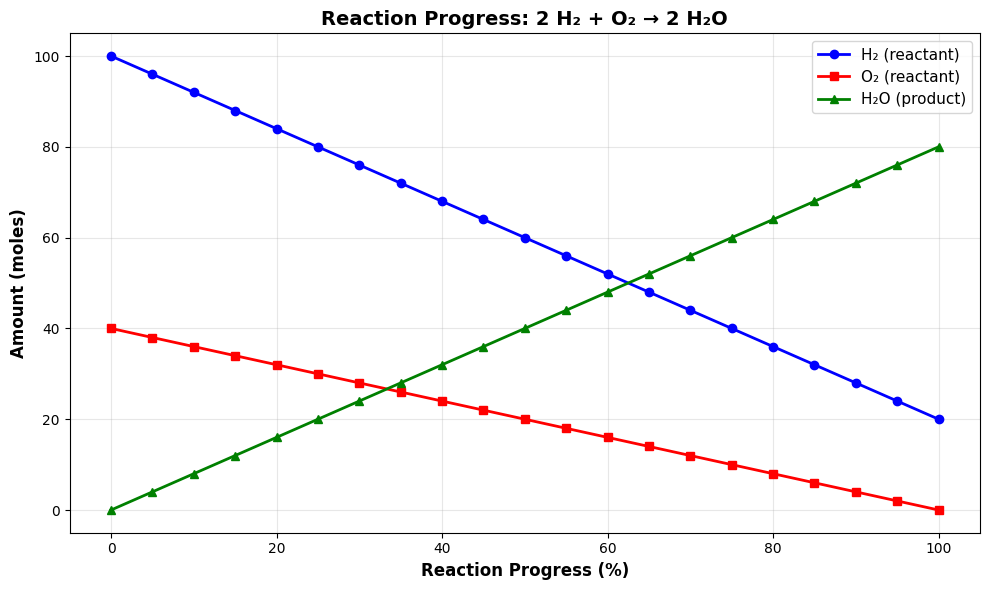


📊 Graph Interpretation:
   • O₂ depletes completely (limiting reagent)
   • H₂ has 20 moles remaining (excess reagent)
   • H₂O production stops when O₂ is consumed
   • Final yield: 80 moles of water


In [8]:
# Example 3b: Visualize reaction progress
print("=== Reaction Progress Visualization ===")
print("Simulating: 2 H₂ + O₂ → 2 H₂O (Hydrogen combustion)\n")

# Initial amounts
initial_h2 = 100  # moles
initial_o2 = 40   # moles
initial_h2o = 0   # moles

# Stoichiometry: 2 H2 : 1 O2 : 2 H2O
# Limiting reagent: O2 (40 mol O2 needs 80 mol H2, but we have 100)

# Simulate reaction progress
reaction_steps = 20  # Number of time steps
h2_values = []
o2_values = []
h2o_values = []

for step in range(reaction_steps + 1):
    # Calculate how much has reacted (linear approximation)
    fraction_complete = step / reaction_steps
    
    # O2 is limiting (40 moles total can react)
    o2_reacted = 40 * fraction_complete
    h2_reacted = 2 * o2_reacted  # 2:1 ratio
    h2o_formed = 2 * o2_reacted  # 2 moles H2O per mole O2
    
    # Current amounts
    current_h2 = initial_h2 - h2_reacted
    current_o2 = initial_o2 - o2_reacted
    current_h2o = initial_h2o + h2o_formed
    
    h2_values.append(current_h2)
    o2_values.append(current_o2)
    h2o_values.append(current_h2o)

# Create the plot
plt.figure(figsize=(10, 6))
time_points = np.linspace(0, 100, reaction_steps + 1)

plt.plot(time_points, h2_values, label='H₂ (reactant)', marker='o', linewidth=2, color='blue')
plt.plot(time_points, o2_values, label='O₂ (reactant)', marker='s', linewidth=2, color='red')
plt.plot(time_points, h2o_values, label='H₂O (product)', marker='^', linewidth=2, color='green')

plt.xlabel('Reaction Progress (%)', fontsize=12, fontweight='bold')
plt.ylabel('Amount (moles)', fontsize=12, fontweight='bold')
plt.title('Reaction Progress: 2 H₂ + O₂ → 2 H₂O', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Graph Interpretation:")
print("   • O₂ depletes completely (limiting reagent)")
print("   • H₂ has 20 moles remaining (excess reagent)")
print("   • H₂O production stops when O₂ is consumed")
print("   • Final yield: 80 moles of water")

In [9]:
# Example 3c: Percent yield calculator
print("=== Percent Yield Analysis ===")
print("Real reactions never reach 100% yield\n")

def calculate_percent_yield(theoretical, actual):
    """
    Calculate percent yield of a reaction
    Percent Yield = (Actual Yield / Theoretical Yield) × 100%
    """
    if theoretical <= 0:
        return "Error: Theoretical yield must be positive"
    
    percent_yield = (actual / theoretical) * 100
    return percent_yield

# Example: Aspirin synthesis in university lab
print("--- Example: Student Lab Aspirin Synthesis ---")
theoretical_yield = 5.0  # grams (calculated from stoichiometry)
actual_yield = 3.8       # grams (what student actually obtained)

percent_yield = calculate_percent_yield(theoretical_yield, actual_yield)

print(f"Theoretical yield: {theoretical_yield} g")
print(f"Actual yield: {actual_yield} g")
print(f"Percent yield: {percent_yield:.1f}%")

# Interpret the result
print("\n📋 Interpretation:")
if percent_yield >= 90:
    print("   ✅ Excellent! Very efficient reaction")
elif percent_yield >= 70:
    print("   ✅ Good! Acceptable for most purposes")
elif percent_yield >= 50:
    print("   ⚠️ Moderate. Room for improvement")
else:
    print("   ❌ Low. Check procedure for errors")

print("\nCommon reasons for low yield:")
print("   • Product lost during filtration/transfer")
print("   • Incomplete reaction")
print("   • Side reactions forming unwanted products")
print("   • Product decomposition")

# Industrial comparison
print("\n--- Industrial Example: Sulfuric Acid Production ---")
theoretical_industrial = 10000  # kg
actual_industrial = 9700        # kg

industrial_yield = calculate_percent_yield(theoretical_industrial, actual_industrial)
print(f"Theoretical: {theoretical_industrial} kg")
print(f"Actual: {actual_industrial} kg")
print(f"Percent yield: {industrial_yield:.1f}%")
print("\n💰 Industrial plants aim for >95% yield to maximize profit!")

=== Percent Yield Analysis ===
Real reactions never reach 100% yield

--- Example: Student Lab Aspirin Synthesis ---
Theoretical yield: 5.0 g
Actual yield: 3.8 g
Percent yield: 76.0%

📋 Interpretation:
   ✅ Good! Acceptable for most purposes

Common reasons for low yield:
   • Product lost during filtration/transfer
   • Incomplete reaction
   • Side reactions forming unwanted products
   • Product decomposition

--- Industrial Example: Sulfuric Acid Production ---
Theoretical: 10000 kg
Actual: 9700 kg
Percent yield: 97.0%

💰 Industrial plants aim for >95% yield to maximize profit!


### 🎯 Key Python Concepts (Example 3):
- **Stoichiometric calculations**: Using ratios to predict products
- **Conditional logic**: Determining limiting reagents
- **NumPy arrays**: Efficient numerical operations with `np.linspace()`
- **Animation concepts**: Simulating reaction progress
- **Functions with validation**: Checking inputs before calculation

---

## 🎓 Summary: What You've Learned

### Chemistry Applications:
✅ Automatic equation balancing  
✅ Molecular property calculations  
✅ Limiting reagent identification  
✅ Percent yield analysis  
✅ Reaction progress simulation  

### Python Skills:
✅ Using specialized libraries (ChemPy)  
✅ Working with molecular formulas  
✅ Simulating chemical processes  
✅ Creating informative visualizations  
✅ Building practical calculators  

---

## 💪 Practice Exercises:

1. **Balance this equation**: Fe + O₂ → Fe₂O₃ (rust formation)
2. **Calculate** the molar mass and nitrogen content of Urea (NH₂CONH₂) - major fertilizer
3. **Limiting reagent**: If you have 50 mol Mg and 30 mol O₂ for 2 Mg + O₂ → 2 MgO, which is limiting?

---

## 🎉 Congratulations!

You've completed all three lessons! You now have practical Python skills for:
- Basic calculations (pH, molar mass, dilutions)
- Data analysis and visualization
- Computational chemistry

### 🚀 Next Steps:
- Practice with your own chemistry problems
- Explore more ChemPy features: equilibrium calculations, kinetics
- Learn about RDKit for advanced cheminformatics
- Apply Python in your research or lab work

### 📚 Resources:
- ChemPy Documentation: https://github.com/bjodah/chempy
- Python for Chemists: http://www.python-for-chemists.com
- Free Practice: https://www.codecademy.com/learn/learn-python-3

**Keep coding and chemistry-ing! 🧪💻🚀**